In [1]:
# ── Libraries ──────────────────────────────────────────────────────────────────

# Data manipulation and numerical computation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning — model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# XGBoost — gradient boosting algorithm
from xgboost import XGBRegressor

# Set a consistent visual theme for all plots
sns.set_theme(style="darkgrid", palette="muted")

In [2]:
# ── Load Dataset ───────────────────────────────────────────────────────────────

# Load the insurance dataset from local directory
df = pd.read_csv(r"D:\Pawani_Personal\Portfolio Building\insurance.csv")

# Check dimensions - (expect 1338 rows and 7 columns)
print("Dataset shape:", df.shape)

# Preview the first 5 rows to confirm data loaded correctly
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Null values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


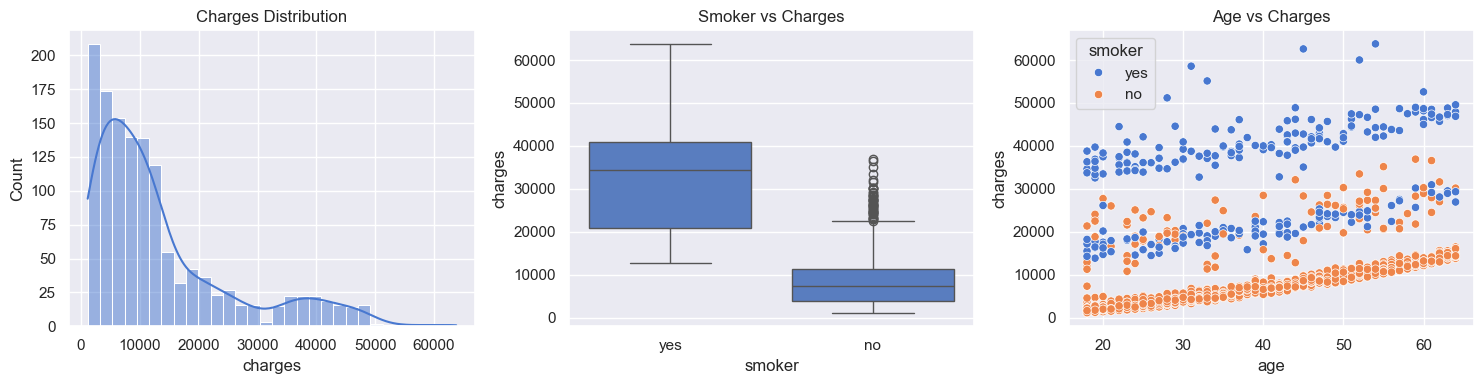

In [3]:
# ── Exploratory Data Analysis (EDA) ───────────────────────────────────────────

# Summary statistics — check range, mean, and spread of numerical columns
print("Summary Statistics:")
print(df.describe())

# Check for missing values — clean data is essential before modelling
print("\nNull values per column:")
print(df.isnull().sum())

# ── Visualisations ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Distribution of insurance charges
# Right skew expected — most people pay low charges, few pay very high
sns.histplot(df['charges'], kde=True, ax=axes[0]).set_title('Charges Distribution')

# Chart 2: Smoker vs Non-smoker charges
# Hypothesis: smokers pay significantly higher premiums
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1]).set_title('Smoker vs Charges')

# Chart 3: Age vs charges, coloured by smoking status
# Hypothesis: charges increase with age, smokers consistently higher
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[2]).set_title('Age vs Charges')

plt.tight_layout()
plt.show()

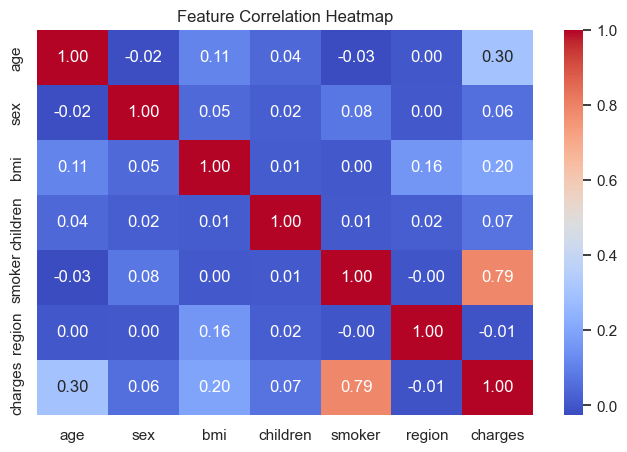

In [4]:
# ── Feature Correlation Heatmap ────────────────────────────────────────────────

# ML models require numerical inputs only
# Encode categorical columns: sex, smoker, region → integers
le = LabelEncoder()
df_encoded = df.copy()  # preserve original dataframe

for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df[col])
    # e.g. smoker: yes=1, no=0 | sex: male=1, female=0

# Correlation heatmap — values close to 1 or -1 indicate strong relationships
# Key question: which features correlate most strongly with charges?
plt.figure(figsize=(8, 5))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
# ── Feature & Target Separation ────────────────────────────────────────────────

# X = input features (age, sex, bmi, children, smoker, region)
X = df_encoded.drop('charges', axis=1)

# y = target variable we want to predict (insurance charges in USD)
y = df_encoded['charges']

# ── Train/Test Split ───────────────────────────────────────────────────────────

# Split: 80% training data, 20% test data
# random_state=42 ensures reproducibility — same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

Training set size: (1070, 6)
Test set size:     (268, 6)


In [6]:
# ── Model Training & Evaluation ────────────────────────────────────────────────

# Three models chosen to compare simple vs complex approaches:
# 1. Linear Regression  — baseline, assumes linear relationships
# 2. Random Forest      — ensemble of decision trees, handles non-linearity
# 3. XGBoost            — gradient boosting, typically highest accuracy

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
    # Train the model on training data
    model.fit(X_train, y_train)

    # Predict on unseen test data
    preds = model.predict(X_test)

    # Evaluate performance:
    # RMSE — average prediction error in dollars (lower = better)
    # R²   — proportion of variance explained by the model (closer to 1 = better)
    results[name] = {
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        "R²":   round(r2_score(y_test, preds), 4)
    }

# Display results as a comparison table
results_df = pd.DataFrame(results).T
print(results_df)

                      RMSE      R²
Linear Regression  5799.59  0.7833
Random Forest      4590.57  0.8643
XGBoost            4822.99  0.8502


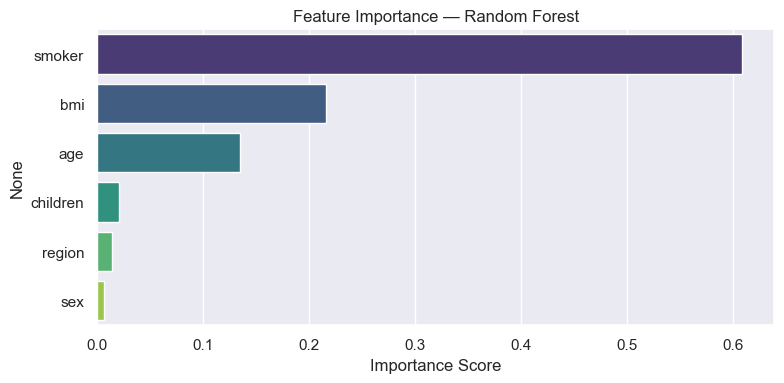

In [7]:
# ── Feature Importance — Random Forest ─────────────────────────────────────────

# Extract the trained Random Forest model
rf_model = models["Random Forest"]

# feature_importances_ shows how much each feature contributed to predictions
# Higher score = more influential in reducing prediction error
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Visualise as a horizontal bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x=importance.values, y=importance.index, palette="viridis",
            hue=importance.index, legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()